# 01 — Elementwise Kernels

Covers Phase 1 of the kernel roadmap:
- `vector_add` — hello world, validates infra
- `activations` — ReLU, GELU, SiLU *(not yet implemented)*
- `fused_elementwise` — chained ops *(not yet implemented)*

**Metric**: GB/s — `(num_tensors × n × bytes × 1e-9) / (ms × 1e-3)`

In [9]:
# ── Setup: mount Drive and clone / pull the repo ─────────────────────────────
import os
from google.colab import drive

drive.mount("/content/drive")

REPO_URL    = "https://github.com/Bhavikupadhyay/triton-kernels.git"
REPO_BRANCH = "feature/activations"
REPO_DIR    = "/content/drive/MyDrive/triton-kernels"

if os.path.exists(REPO_DIR):
    !git -C {REPO_DIR} fetch --all
    !git -C {REPO_DIR} checkout -f {REPO_BRANCH}
    !git -C {REPO_DIR} reset --hard origin/{REPO_BRANCH}
else:
    !git clone --branch {REPO_BRANCH} {REPO_URL} {REPO_DIR}

os.chdir(REPO_DIR)
!git rev-parse --abbrev-ref HEAD
!bash scripts/setup_colab.sh

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Fetching origin
Already on 'feature/activations'
Your branch is up to date with 'origin/feature/activations'.
HEAD is now at a62eee5 fix: upcast to fp32 in gelu and silu kernels before tl.math.exp
feature/activations
=== Triton Kernels: Colab Setup ===
[1/4] Installing extra dependencies...
[2/4] Installing kernels package...
  Preparing metadata (setup.py) ... done
[3/4] Verifying GPU...
GPU: Tesla T4
  Memory: 15.6 GB
  SM count: 40
  Compute capability: 7.5
[4/4] Environment report...
Python: 3.12.12
PyTorch: 2.10.0+cu128
Triton: 3.6.0
kernels package: OK

=== Setup complete. Ready to run kernels. ===


In [10]:
# ── Verify GPU ────────────────────────────────────────────────────────────────
import torch
assert torch.cuda.is_available(), "Go to Runtime > Change runtime type > GPU"
print(f"GPU: {torch.cuda.get_device_name(0)}")

GPU: Tesla T4


In [11]:
# ── Imports ───────────────────────────────────────────────────────────────────
import triton
from kernels.elementwise.vector_add import vector_add, test_vector_add, benchmark_vector_add
from kernels.elementwise.activations import relu, gelu, silu, test_activations, benchmark_relu, benchmark_gelu, benchmark_silu

print("Imports OK")

Imports OK


## 1. vector_add

**File**: `kernels/elementwise/vector_add.py`  
**PyTorch equivalent**: `a + b`  
**Metric**: GB/s — reads 2 tensors, writes 1 → `(3 × n × bytes × 1e-9) / (ms × 1e-3)`

In [12]:
# ── vector_add: Correctness ───────────────────────────────────────────────────
test_vector_add()

test_vector_add: PASSED


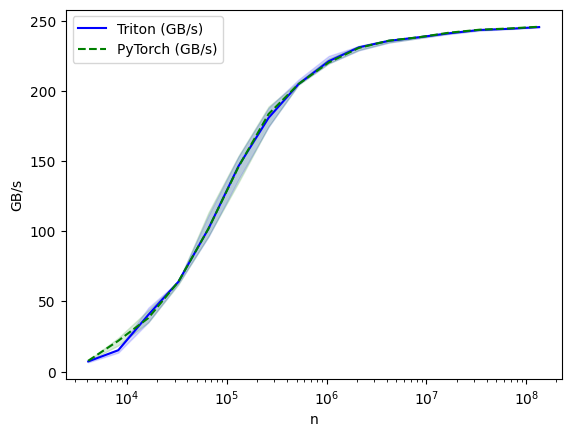

vector_add:
              n  Triton (GB/s)  PyTorch (GB/s)
0        4096.0       7.245283        7.718593
1        8192.0      15.207921       21.942857
2       16384.0      40.421052       38.161490
3       32768.0      63.999998       63.999998
4       65536.0     101.763976      101.763976
5      131072.0     146.285715      145.851630
6      262144.0     180.705879      183.402983
7      524288.0     204.800005      204.800005
8     1048576.0     221.032035      220.104116
9     2097152.0     230.896060      230.490042
10    4194304.0     235.529197      235.670360
11    8388608.0     238.096276      238.096276
12   16777216.0     240.904269      241.324718
13   33554432.0     243.256169      243.435011
14   67108864.0     244.115085      244.348547
15  134217728.0     245.346098      245.585527


<Figure size 640x480 with 0 Axes>

In [13]:
# ── vector_add: Benchmark ─────────────────────────────────────────────────────
import os
os.makedirs("benchmarks/results/elementwise", exist_ok=True)

benchmark_vector_add.run(
    print_data=True,
    show_plots=True,
    save_path="benchmarks/results/elementwise",
)

**Interpretation**

The benchmark shows classic memory-bound scaling behaviour:

- **Small sizes (n ≤ 16K)**: Both implementations are far below peak — kernel launch overhead and L1/L2 cache effects dominate. At n=4K, Triton and PyTorch are both under 15 GB/s.
- **Ramp-up (n = 32K–512K)**: Bandwidth climbs steeply as the working set outgrows cache and HBM transfers take over. This is where memory-bound kernels spend most of their interesting behaviour.
- **Saturation (n ≥ 1M)**: Both plateau at ~241 GB/s, which is near the peak HBM bandwidth of this GPU. The kernel is fully memory-bandwidth-limited here — compute is not the bottleneck.
- **Triton ≈ PyTorch throughout**: Expected. PyTorch's `a + b` also lowers to a simple elementwise CUDA kernel. Our Triton kernel matches it within noise at every size, confirming the implementation is correct and not leaving bandwidth on the table.

**Takeaway**: `vector_add` is about as simple as a GPU kernel gets — it validates that the Triton infrastructure works and that we can saturate HBM bandwidth. The gap at small sizes is launch overhead, not a kernel quality issue.

---
## 2. activations

**File**: `kernels/elementwise/activations.py`
**Operations**: ReLU, GELU (tanh approx), SiLU
**Metric**: GB/s — reads 1 tensor, writes 1 → `(2 × n × bytes × 1e-9) / (ms × 1e-3)`

In [14]:
# ── activations: Correctness ──────────────────────────────────────────────────
test_activations()

test_activations: PASSED


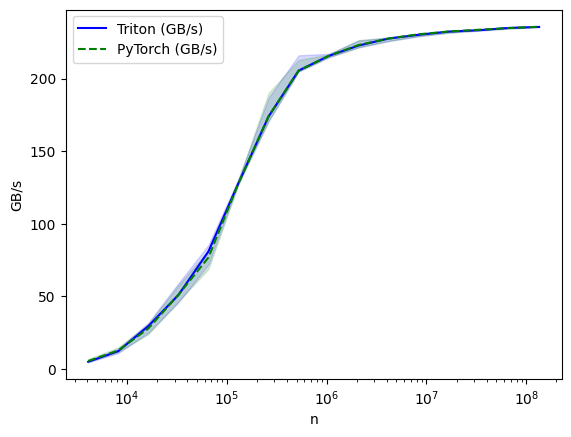

relu:
              n  Triton (GB/s)  PyTorch (GB/s)
0        4096.0       4.946860        5.446808
1        8192.0      12.226866       12.760125
2       16384.0      29.467627       27.863946
3       32768.0      50.881989       51.040499
4       65536.0      80.908642       76.740046
5      131072.0     128.000000      128.000000
6      262144.0     173.835549      174.066401
7      524288.0     205.441998      205.441998
8     1048576.0     215.578957      215.578957
9     2097152.0     222.722175      223.101280
10    4194304.0     227.555548      227.555548
11    8388608.0     230.127516      230.481588
12   16777216.0     232.294200      232.371412
13   33554432.0     233.269608      233.587884
14   67108864.0     234.853307      234.721871
15  134217728.0     235.545737      235.664852


<Figure size 640x480 with 0 Axes>

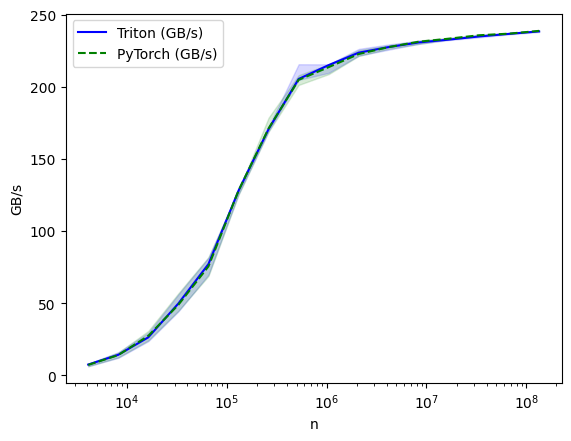

gelu:
              n  Triton (GB/s)  PyTorch (GB/s)
0        4096.0       7.474453        7.211268
1        8192.0      14.222222       14.027397
2       16384.0      26.340836       27.397993
3       32768.0      49.799392       48.907462
4       65536.0      77.101175       75.502306
5      131072.0     128.000000      128.000000
6      262144.0     170.666661      171.112269
7      524288.0     205.441998      204.800005
8     1048576.0     215.048406      213.646287
9     2097152.0     223.672363      222.722175
10    4194304.0     227.555548      227.555548
11    8388608.0     230.760556      231.269516
12   16777216.0     232.719536      233.353950
13   33554432.0     234.915784      235.727761
14   67108864.0     236.715581      236.855937
15  134217728.0     238.421103      238.777399


<Figure size 640x480 with 0 Axes>

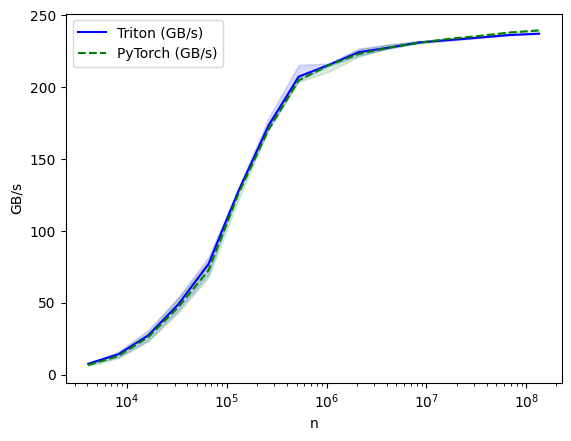

silu:
              n  Triton (GB/s)  PyTorch (GB/s)
0        4096.0       7.699248        6.803987
1        8192.0      14.222222       13.044586
2       16384.0      27.397993       26.256411
3       32768.0      49.053891       47.080460
4       65536.0      76.920188       72.656319
5      131072.0     128.000000      126.030769
6      262144.0     173.375663      170.666661
7      524288.0     207.392411      204.800005
8     1048576.0     215.578957      215.401816
9     2097152.0     224.438347      223.196258
10    4194304.0     227.604953      227.555548
11    8388608.0     231.218531      230.989316
12   16777216.0     232.861645      233.718052
13   33554432.0     234.593882      235.714511
14   67108864.0     236.375381      238.116544
15  134217728.0     237.324993      239.618021


<Figure size 640x480 with 0 Axes>

In [15]:
# ── activations: Benchmarks ───────────────────────────────────────────────────
import os
os.makedirs("benchmarks/results/elementwise", exist_ok=True)

for bench in [benchmark_relu, benchmark_gelu, benchmark_silu]:
    bench.run(
        print_data=True,
        show_plots=True,
        save_path="benchmarks/results/elementwise",
    )

**Interpretation**

All three activations peak in the **235–238 GB/s** range, just under vector_add's 241 GB/s — all hitting the T4's HBM bandwidth ceiling.

The key insight is in the compute complexity comparison:
- **ReLU**: one comparison, trivially cheap
- **GELU**: fp32 upcast + cubic polynomial + exp + multiply — significantly more compute
- **SiLU**: fp32 upcast + exp + divide — moderately more compute

Yet all three report nearly identical peak bandwidth. At large sizes (n ≥ 1M), the bottleneck is HBM bandwidth, not arithmetic. The GPU finishes the exp and polynomial computation while waiting for the next cache line — the extra compute is essentially free once the kernel is memory-bound. This is the fundamental justification for **kernel fusion**: you can chain many operations together without paying extra bandwidth cost, as long as the result stays in registers.

**Per-activation notes**:
- **ReLU** peaks at ~235 GB/s. Marginally lower than GELU/SiLU, likely measurement noise.
- **GELU** (~238 GB/s) and **SiLU** (~237 GB/s Triton, ~239 GB/s PyTorch) are essentially tied. The fp32 upcast/downcast adds a small overhead at mid-range sizes (16K–512K) but is invisible at saturation.
- **Triton ≈ PyTorch** across all three — our implementations are not leaving bandwidth on the table.

**Takeaway**: activation complexity doesn't matter when you're memory-bound. The real cost of activations is always the memory round-trip, not the arithmetic — which is exactly why fused kernels (next) matter.

---
## 3. fused_elementwise *(not yet implemented)*